# Predicting F10.7 Solar Radio Flux using SDOFMv2

## Background
This notebook serves as a practical demonstration of utilizing the SDOFMv2 model to predict solar irradiance flux. While predicting a proxy measure like the F10.7 index may have limited direct scientific application, the results presented here—summarized in a single concluding plot—clearly illustrate the model's robust feature representation and learned capacity.

## Process
Our approach leverages the latent space representations extracted from the SDOFMv2 encoder. These latents are then fed into a simple Multi-Layer Perceptron (MLP) to predict the F10.7 index. 

The workflow is structured into three main steps:
1. **Setup:** Defining the model architectures and initializing the data loaders.
2. **Training:** Training the MLP using the extracted latents as inputs.
3. **Evaluation:** Visualizing the predictions against ground-truth data for comparison.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from loguru import logger
from omegaconf import OmegaConf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import lightning as l
from lightning.pytorch.callbacks import ModelCheckpoint

from sdofmv2.core import MAE, MAE_old
from sdofmv2.tasks.f107 import EmbSolarProxyDataModule, MultiLayerPerceptron

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize three dataloaders from SDOFMv2-AIA, SDOFMv2-HIM, and SDOFMv1
cfg_AIA = OmegaConf.load("../../../configs/downstream/finetune_f107_config_sdofmv2_AIA.yaml")
cfg_HMI = OmegaConf.load("../../../configs/downstream/finetune_f107_config_sdofmv2_HMI.yaml")
cfg_old = OmegaConf.load("../../../configs/downstream/finetune_f107_config_sdofmv1.yaml")

data_module_AIA = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_AIA.data.sdoml.base_directory, 
        cfg_AIA.data.sdoml.sub_directory.hmi
    ) if cfg_AIA.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_AIA.data.sdoml.base_directory,
        cfg_AIA.data.sdoml.sub_directory.aia,
    ) if cfg_AIA.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_AIA.data.sdoml.components,
    wavelengths=cfg_AIA.data.sdoml.wavelengths,
    ions=cfg_AIA.data.sdoml.ions,
    frequency=cfg_AIA.data.sdoml.frequency,
    batch_size=cfg_AIA.model.misc.batch_size,
    num_workers=cfg_AIA.data.num_workers,
    pin_memory=cfg_AIA.data.pin_memory,
    persistent_workers=cfg_AIA.data.persistent_workers,
    val_months=cfg_AIA.data.month_splits.val,
    test_months=cfg_AIA.data.month_splits.test,
    holdout_months=cfg_AIA.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_AIA.data.min_date,
    max_date=cfg_AIA.data.max_date,
    num_frames=cfg_AIA.model.mae.num_frames,
    drop_frame_dim=cfg_AIA.data.drop_frame_dim,
    apply_mask=cfg_AIA.data.sdoml.apply_mask,
    precision=cfg_AIA.experiment.precision,
    normalization=cfg_AIA.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_AIA.setup()

data_module_HMI = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_HMI.data.sdoml.base_directory, 
        cfg_HMI.data.sdoml.sub_directory.hmi
    ) if cfg_HMI.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_HMI.data.sdoml.base_directory,
        cfg_HMI.data.sdoml.sub_directory.aia,
    ) if cfg_HMI.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_HMI.data.sdoml.components,
    wavelengths=cfg_HMI.data.sdoml.wavelengths,
    ions=cfg_HMI.data.sdoml.ions,
    frequency=cfg_HMI.data.sdoml.frequency,
    batch_size=cfg_HMI.model.misc.batch_size,
    num_workers=cfg_HMI.data.num_workers,
    pin_memory=cfg_HMI.data.pin_memory,
    persistent_workers=cfg_HMI.data.persistent_workers,
    val_months=cfg_HMI.data.month_splits.val,
    test_months=cfg_HMI.data.month_splits.test,
    holdout_months=cfg_HMI.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_HMI.data.min_date,
    max_date=cfg_HMI.data.max_date,
    num_frames=cfg_HMI.model.mae.num_frames,
    drop_frame_dim=cfg_HMI.data.drop_frame_dim,
    apply_mask=cfg_HMI.data.sdoml.apply_mask,
    precision=cfg_HMI.experiment.precision,
    normalization=cfg_HMI.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_HMI.setup()

data_module_for_old = EmbSolarProxyDataModule(
    hmi_path=os.path.join(
        cfg_old.data.sdoml.base_directory, 
        cfg_old.data.sdoml.sub_directory.hmi
    ) if cfg_old.data.sdoml.sub_directory.hmi else None,
    aia_path=os.path.join(
        cfg_old.data.sdoml.base_directory,
        cfg_old.data.sdoml.sub_directory.aia,
    ) if cfg_old.data.sdoml.sub_directory.aia else None,
    eve_path=None,
    components=cfg_old.data.sdoml.components,
    wavelengths=cfg_old.data.sdoml.wavelengths,
    ions=cfg_old.data.sdoml.ions,
    frequency=cfg_old.data.sdoml.frequency,
    batch_size=cfg_old.model.misc.batch_size,
    num_workers=cfg_old.data.num_workers,
    val_months=cfg_old.data.month_splits.val,
    test_months=cfg_old.data.month_splits.test,
    holdout_months=cfg_old.data.month_splits.holdout,
    cache_dir="../../../assets/cache/",
    min_date=cfg_old.data.min_date,
    max_date=cfg_old.data.max_date,
    num_frames=cfg_old.model.mae.num_frames,
    drop_frame_dim=cfg_old.data.drop_frame_dim,
    apply_mask=cfg_old.data.sdoml.apply_mask,
    precision=cfg_old.experiment.precision,
    normalization=cfg_old.data.sdoml.normalization,
    ds_data_path="f10.7.csv",
)
data_module_for_old.setup()

[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-10 01:47:49.716 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:49.716 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:49.717 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:49.718 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:49.718 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:49.719 | INFO     | s

[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.
[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_HMI_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-10 01:47:50.033 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//HMI/Bx_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:50.034 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//HMI/By_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:50.034 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//HMI/Bz_2010-05-0100:00:00-2018-12-3123:59:59_norm-log.json
2026-03-10 01:47:50.066 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:156 - Train dataloader is ready!
2026-03-10 01:47:50.067 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:157 - Dataset size: 3709
2026-03-10 01:47:50.068 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:179 - Validation dataloader is ready!
2026-03-10 01:47:50.068 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:180 - Dataset size: 46

[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.
[* CACHE SYSTEM *] Found cached index data in ../../../assets/cache//aligndata_AIA_FULL_12min_2010-05-0100:00:00-2018-12-3123:59:59.csv.


2026-03-10 01:47:50.371 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/131A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-10 01:47:50.373 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1600A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-10 01:47:50.373 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/1700A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-10 01:47:50.373 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/171A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-10 01:47:50.374 | INFO     | sdofmv2.core.datamodule:check_existing_stat_info:924 - Cache is found: ../../../assets/cache//AIA/193A_2010-05-0100:00:00-2018-12-3123:59:59_norm-zscore.json
2026-03-10 01:47:50.375

[* CACHE SYSTEM *] Found cached HMI mask data in ../../../assets/cache//hmi_mask_512x512.npy.


In [3]:
print("Data for sdofmv2 AIA")
print(f"Num sampels in training set: {len(data_module_AIA.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_AIA.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_AIA.test_ds)}")

print("\nData for sdofmv2 HMI")
print(f"Num sampels in training set: {len(data_module_HMI.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_HMI.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_HMI.test_ds)}")

print("\nData for sdofmv1")
print(f"Num sampels in training set: {len(data_module_for_old.train_ds)}")
print(f"Num sampels in validation set: {len(data_module_for_old.valid_ds)}")
print(f"Num sampels in test set: {len(data_module_for_old.test_ds)}")

Data for sdofmv2 AIA
Num sampels in training set: 2073
Num sampels in validation set: 264
Num sampels in test set: 794

Data for sdofmv2 HMI
Num sampels in training set: 3709
Num sampels in validation set: 468
Num sampels in test set: 1423

Data for sdofmv1
Num sampels in training set: 2073
Num sampels in validation set: 264
Num sampels in test set: 794


In [4]:
# load pretrained weights
ckpt_dir = "../../../assets/check_point/backbone/"
backbone_sdofmv2_AIA = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "AIA/AIA_MSEloss_epoch=171-val_loss=0.00_only_weights.ckpt", 
    map_location="cpu",
    weights_only=False)
logger.info(f"masking ratio of sdofmv2: {backbone_sdofmv2_AIA.masking_ratio}")

backbone_sdofmv2_HMI = MAE.load_from_checkpoint(
    checkpoint_path= ckpt_dir + "HMI/id_mycczy8p_mae_epoch=299-val_loss=0.03_only_weights.ckpt", 
    map_location="cpu",
    weights_only=False)
logger.info(f"masking ratio of sdofmv2: {backbone_sdofmv2_HMI.masking_ratio}")

backbone_sdofmv1 = MAE_old.load_from_checkpoint(
    checkpoint_path=ckpt_dir + "pretrained_mae_e128.ckpt", 
    map_location="cpu",
    weights_only=False,
    optimizer_dict=cfg_HMI.model.optimizer,
    scheduler_dict=cfg_HMI.model.scheduler)
logger.info(f"masking ratio of sdofmv1: {backbone_sdofmv1.masking_ratio}")

2026-03-08 04:53:32.126 | INFO     | __main__:<module>:7 - masking ratio of sdofmv2: 0.5
2026-03-08 04:53:32.914 | INFO     | __main__:<module>:13 - masking ratio of sdofmv2: 0.5
2026-03-08 04:53:34.026 | INFO     | __main__:<module>:21 - masking ratio of sdofmv1: 0.5


In [5]:
# downstream model from SDOFMv1
model_sdofmv1 = MultiLayerPerceptron(
    backbone=backbone_sdofmv1, 
    freeze=True, 
    input_dim=512,
    mask_ratio=0.5,
    optimizer_dict=cfg_old.model.optimizer,
    scheduler_dict=cfg_old.model.scheduler
    )

checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_aia_sdofmv1_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

os.environ["PJRT_DEVICE"] = "GPU"
# If there is a GPU attached, use it
if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv1 = l.Trainer(
        max_epochs=cfg_old.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv1 = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [6]:
# Begin training
if not os.path.exists("mae_aia_sdofmv1_best.ckpt"):
    trainer_sdofmv1.fit(
        model=model_sdofmv1, 
        datamodule=data_module_for_old)
    
else:
    logger.info("Pass training, ckpt exists!")

You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
2026-03-08 04:53:34.427 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:156 - Train dataloader is ready!
2026-03-08 04:53:34.428 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:157 - Dataset size: 2073
2026-03-08 04:53:34.429 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:179 - Validation dataloader is ready!
2026-03-08 04:53:34.429 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:180 - Dataset size: 264
2026-03-08 04:53:34.430 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:202 - test dataloader is ready!
2026-03-08 04:53:34.430 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:203 - Dataset si

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MAE_old    │  104 M │ eval  │     0 │
│ 1 │ norm      │ LayerNorm  │  2.0 K │ train │     0 │
│ 2 │ dropout   │ Dropout    │      0 │ train │     0 │
│ 3 │ fcs       │ ModuleList │  1.1 M │ train │     0 │
│ 4 │ acts      │ ModuleList │      0 │ train │     0 │
│ 5 │ fc_out    │ Linear     │    513 │ train │     0 │
│ 6 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 104 M                                                                                        
Total params: 105 M                                                                                                
Total estimated model params size (MB): 422                                                                        
Modules in train mode: 12                                                                                          
Modules in eval mode: 715                                                                                          
Total FLOPs: 0

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 715
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [7]:
# downstream model from SDOFMv2-AIA
model_sdofmv2_AIA = MultiLayerPerceptron(
    backbone=backbone_sdofmv2_AIA, 
    freeze=True, 
    input_dim=768,
    mask_ratio=0,
    optimizer_dict=cfg_AIA.model.optimizer,
    scheduler_dict=cfg_AIA.model.scheduler
    )
checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_aia_sdofmv2_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv2_AIA = l.Trainer(
        max_epochs=cfg_AIA.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv2_AIA = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [8]:
# Begin training
if not os.path.exists("mae_aia_sdofmv2_best.ckpt"):
    trainer_sdofmv2_AIA.fit(
        model=model_sdofmv2_AIA, 
        datamodule=data_module_AIA)
    
else:
    logger.info("Pass training, ckpt exists!")


2026-03-08 05:53:44.409 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:156 - Train dataloader is ready!
2026-03-08 05:53:44.410 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:157 - Dataset size: 2073
2026-03-08 05:53:44.412 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:179 - Validation dataloader is ready!
2026-03-08 05:53:44.412 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:180 - Dataset size: 264
2026-03-08 05:53:44.414 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:202 - test dataloader is ready!
2026-03-08 05:53:44.414 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:203 - Dataset size: 794
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/jinsu/project/sdofmv2/notebooks/downstream_apps/F10_7 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-03-08 05:53:44.907 | DEBUG    | sdofmv2.core.basemodule:configure_optimizers:33 - Ini

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MAE        │  114 M │ eval  │     0 │
│ 1 │ norm      │ LayerNorm  │  3.1 K │ train │     0 │
│ 2 │ dropout   │ Dropout    │      0 │ train │     0 │
│ 3 │ fcs       │ ModuleList │  1.3 M │ train │     0 │
│ 4 │ acts      │ ModuleList │      0 │ train │     0 │
│ 5 │ fc_out    │ Linear     │    513 │ train │     0 │
│ 6 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 114 M                                                                                        
Total params: 116 M                                                                                                
Total estimated model params size (MB): 465                                                                        
Modules in train mode: 12                                                                                          
Modules in eval mode: 451                                                                                          
Total FLOPs: 0

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 451
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [9]:
# downstream model from SDOFMv2-HMI
model_sdofmv2_HMI = MultiLayerPerceptron(
    backbone=backbone_sdofmv2_HMI, 
    freeze=True, 
    input_dim=768,
    mask_ratio=0,
    optimizer_dict=cfg_AIA.model.optimizer,
    scheduler_dict=cfg_AIA.model.scheduler
    )
checkpoint_callback = ModelCheckpoint(
    dirpath="./",
    filename="mae_hmi_sdofmv2_best",
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

if torch.cuda.is_available():
    # Devices allow selection of which GPU where mulitple available, precision is floating point accuracy
    trainer_sdofmv2_HMI = l.Trainer(
        max_epochs=cfg_AIA.model.misc.epochs, 
        devices=[0], 
        precision=32, 
        callbacks=[checkpoint_callback])

else:
    trainer_sdofmv2_HMI = l.Trainer(max_epochs=10, devices=[0], precision=32, callbacks=[checkpoint_callback])

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'backbone' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['backbone'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [10]:
# Begin training
if not os.path.exists("mae_hmi_sdofmv2_best.ckpt"):
    trainer_sdofmv2_HMI.fit(
        model=model_sdofmv2_HMI, 
        datamodule=data_module_HMI)
    
else:
    logger.info("Pass training, ckpt exists!")


2026-03-08 07:35:25.719 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:156 - Train dataloader is ready!
2026-03-08 07:35:25.720 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:157 - Dataset size: 3709
2026-03-08 07:35:25.721 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:179 - Validation dataloader is ready!
2026-03-08 07:35:25.722 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:180 - Dataset size: 468
2026-03-08 07:35:25.723 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:202 - test dataloader is ready!
2026-03-08 07:35:25.723 | INFO     | sdofmv2.tasks.f107.f107_datamodule:setup:203 - Dataset size: 1423
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /home/jinsu/project/sdofmv2/notebooks/downstream_apps/F10_7 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
2026-03-08 07:35:26.167 | DEBUG    | sdofmv2.core.basemodule:configure_optimizers:33 - In

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ MAE        │  112 M │ eval  │     0 │
│ 1 │ norm      │ LayerNorm  │  3.1 K │ train │     0 │
│ 2 │ dropout   │ Dropout    │      0 │ train │     0 │
│ 3 │ fcs       │ ModuleList │  1.3 M │ train │     0 │
│ 4 │ acts      │ ModuleList │      0 │ train │     0 │
│ 5 │ fc_out    │ Linear     │    513 │ train │     0 │
│ 6 │ criterion │ MSELoss    │      0 │ train │     0 │
└───┴───────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 112 M                                                                                        
Total params: 114 M                                                                                                
Total estimated model params size (MB): 457                                                                        
Modules in train mode: 12                                                                                          
Modules in eval mode: 451                                                                                          
Total FLOPs: 0

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 451
module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is 
intentional, you can ignore this warning.

`Trainer.fit` stopped: `max_epochs=50` reached.


In [11]:
# Check perfomances on testset using three downstream models
trainer_sdofmv1.test(
    model_sdofmv1, 
    datamodule=data_module_for_old,
    ckpt_path="mae_aia_sdofmv1_best.ckpt",
    weights_only=False)

trainer_sdofmv2_AIA.test(
    model_sdofmv2_AIA, 
    datamodule=data_module_AIA,
    ckpt_path="mae_aia_sdofmv2_best.ckpt",
    weights_only=False)

trainer_sdofmv2_HMI.test(
    model_sdofmv2_HMI, 
    datamodule=data_module_HMI,
    ckpt_path="mae_hmi_sdofmv2_best.ckpt",
    weights_only=False)

Restoring states from the checkpoint path at mae_aia_sdofmv1_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_aia_sdofmv1_best.ckpt


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0009267511777579784   │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at mae_aia_sdofmv2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_aia_sdofmv2_best.ckpt


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0006861691363155842   │
└───────────────────────────┴───────────────────────────┘

Restoring states from the checkpoint path at mae_hmi_sdofmv2_best.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/lightning/pytorch/core/saving.py:365: Skipping 'backbone' parameter because it is not possible to safely dump to YAML.
Loaded model weights from the checkpoint at mae_hmi_sdofmv2_best.ckpt


/home/jinsu/miniforge3/envs/sdofmv2/lib/python3.11/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │   0.0011749629629775882   │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0011749629629775882}]

## Visualization for comparison 

Collect the Google Embeddings model predictions

In [12]:
# Data Organization for Visualization
tp_sdofmv1 = model_sdofmv1.test_preds
tp_sdofmv2_AIA = model_sdofmv2_AIA.test_preds
tp_sdofmv2_HMI = model_sdofmv2_HMI.test_preds


y = []
timestamps = []
preds_sdofmv1 = []
preds_sdofmv2_AIA = []
preds_sdofmv2_HMI = []


for key, values in tp_sdofmv1.items():

    if key not in tp_sdofmv2_HMI.keys():
        continue

    timestamps.append(pd.to_datetime(key).strftime("%Y-%m-%d"))
    preds_sdofmv1.append(values[1] * data_module_for_old.max_norm)
    preds_sdofmv2_AIA.append(tp_sdofmv2_AIA[key][1] * data_module_AIA.max_norm)
    preds_sdofmv2_HMI.append(tp_sdofmv2_HMI[key][1] * data_module_HMI.max_norm)

    y.append(values[0] * data_module_for_old.max_norm)


In [13]:
y = np.array(y)
preds_sdofmv1 = np.array(preds_sdofmv1)
preds_sdofmv2_AIA = np.array(preds_sdofmv2_AIA)
preds_sdofmv2_HMI = np.array(preds_sdofmv2_HMI)

In [14]:
r2_sdofmv1 = r2_score(y, preds_sdofmv1)
r2_sdofmv2_AIA = r2_score(y, preds_sdofmv2_AIA)
r2_sdofmv2_HMI = r2_score(y, preds_sdofmv2_HMI)

mae_sdofmv1 = mean_absolute_error(y, preds_sdofmv1)
mae_sdofmv2_AIA = mean_absolute_error(y, preds_sdofmv2_AIA)
mae_sdofmv2_HMI = mean_absolute_error(y, preds_sdofmv2_HMI)


mse_sdofmv1 = mean_squared_error(y, preds_sdofmv1)
mse_sdofmv2_AIA = mean_squared_error(y, preds_sdofmv2_AIA)
mse_sdofmv2_HMI = mean_squared_error(y, preds_sdofmv2_HMI)


print(f"SDOFMV1, MAE: {mae_sdofmv1:.2f}, MSE: {mse_sdofmv1:.2f}, R^{2}: {r2_sdofmv1:.2f}")
print(f"SDOFMV2_AIA, MAE: {mae_sdofmv2_AIA:.2f}, MSE: {mse_sdofmv2_AIA:.2f}, R^{2}: {r2_sdofmv2_AIA:.2f}")
print(f"SDOFMV2_HMI, MAE: {mae_sdofmv2_HMI:.2f}, MSE: {mse_sdofmv2_HMI:.2f}, R^{2}: {r2_sdofmv2_HMI:.2f}")


SDOFMV1, MAE: 7.78, MSE: 125.14, R^2: 0.88
SDOFMV2_AIA, MAE: 6.70, MSE: 93.24, R^2: 0.91
SDOFMV2_HMI, MAE: 9.43, MSE: 153.92, R^2: 0.85


Collect the SDOFM model predictions

Produce the full comparison plot

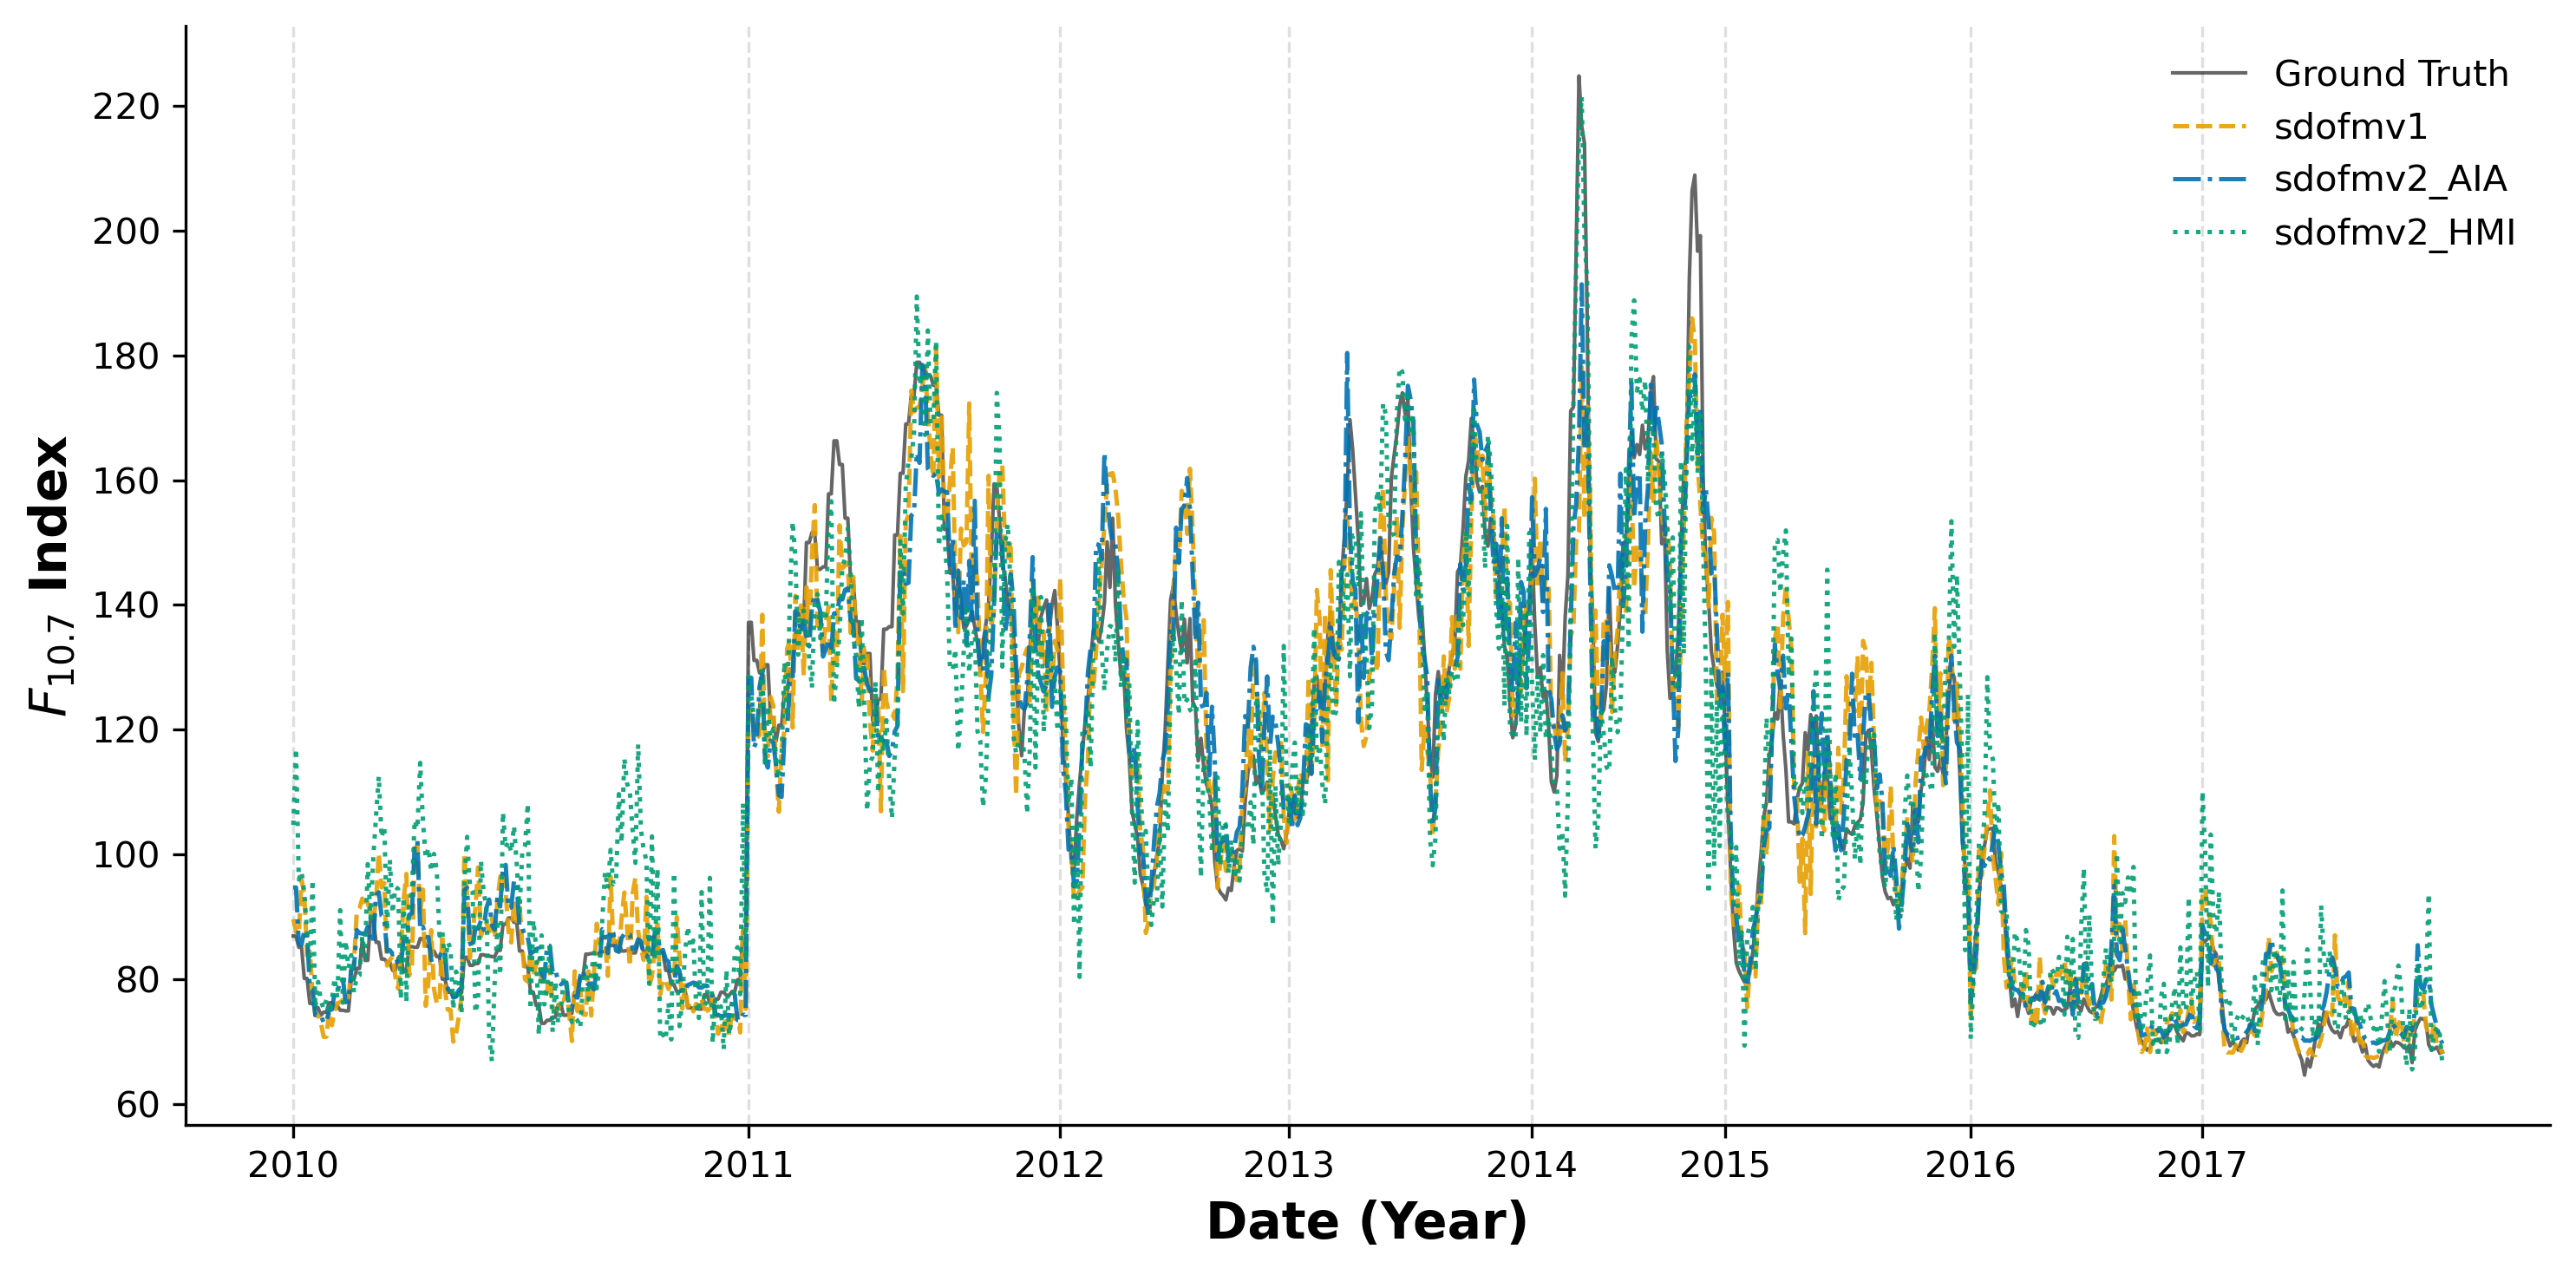

In [15]:
dates = pd.to_datetime(timestamps)
years = dates.year

x_idx = np.arange(len(dates))
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# Ground Truth: Dark grey or Black is better for the "anchor" data
ax.plot(x_idx, y, label="Ground Truth", color='black', linewidth=1, alpha=0.6)

# Model 1: Orange (Okabe-Ito)
ax.plot(x_idx, preds_sdofmv1, label="sdofmv1", color='#E69F00', 
        linewidth=1.2, alpha=0.9, linestyle='--')

# Model 2 (AIA): Darker Blue (Okabe-Ito) - distinct from orange
ax.plot(x_idx, preds_sdofmv2_AIA, label="sdofmv2_AIA", color='#0072B2', 
        linewidth=1.2, alpha=0.9, linestyle='-.')

# Model 2 (HMI): Teal (Okabe-Ito) - much easier to see than lime green
ax.plot(x_idx, preds_sdofmv2_HMI, label="sdofmv2_HMI", color='#009E73', 
        linewidth=1.2, alpha=0.9, linestyle=':')

unique_years, indices = np.unique(years, return_index=True)

ax.set_xticks(indices)
ax.set_xticklabels(unique_years)

ax.set_xlabel("Date (Year)", fontsize=14, fontweight='bold')
ax.set_ylabel("$F_{10.7}$ Index", fontsize=14, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, which='major', axis='x', linestyle='--', alpha=0.4)

ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("f107_result_plot.pdf", format='pdf', bbox_inches='tight')
plt.show()